In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## 数据前处理

In [2]:
# 加载加州房价数据集（回归任务标准数据集）
housing = fetch_california_housing()
X = housing.data  # 特征
y = housing.target  # 标签（房价）
feature_names = housing.feature_names

housing_df = pd.DataFrame(X, columns=feature_names)
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
print(f"数据集特征名称：{feature_names}")
print(f"特征矩阵形状：{X.shape}")
print(f"标签形状：{y.shape}")

数据集特征名称：['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
特征矩阵形状：(20640, 8)
标签形状：(20640,)


### 数据集划分

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集形状：{X_train.shape}")
print(f"测试集形状：{X_test.shape}\n")

训练集形状：(16512, 8)
测试集形状：(4128, 8)



### 特征标准化

In [5]:
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)
print(f"标准化后训练集前2行：\n{X_train_std[:2]}\n")

标准化后训练集前2行：
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]]



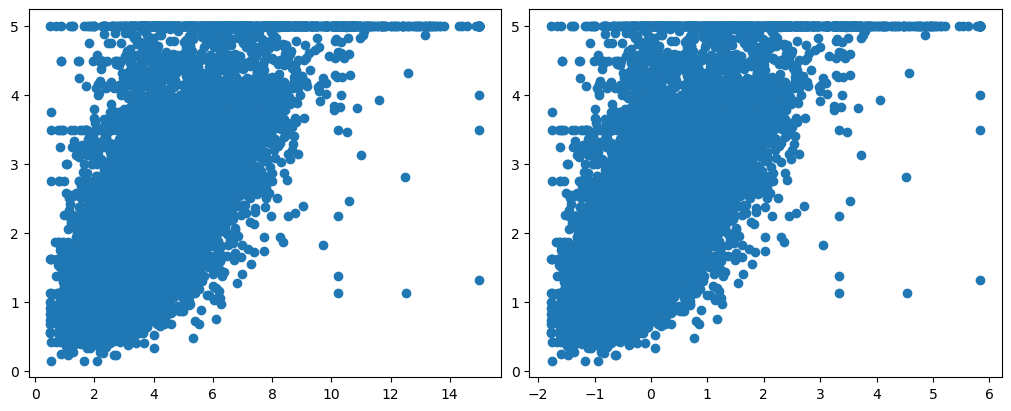

In [6]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=1)

axes[0].scatter(X_train[:, 0], y_train, label="训练集")
axes[1].scatter(X_train_std[:, 0], y_train, label="训练集")

### 特征归一化

In [7]:
minmax_scaler = MinMaxScaler()
X_train_norm = minmax_scaler.fit_transform(X_train)
X_test_norm = minmax_scaler.transform(X_test)
print(f"归一化后训练集前2行：\n{X_train_norm[:2]}")

归一化后训练集前2行：
[[1.90321513e-01 6.27450980e-01 2.92778450e-02 2.66010515e-02
  6.43796071e-02 2.41381545e-03 1.70212766e-02 7.29083665e-01]
 [2.28452021e-01 9.41176471e-01 2.54194508e-02 2.79678738e-02
  3.67443034e-02 8.41584596e-04 1.29787234e-01 6.16533865e-01]]


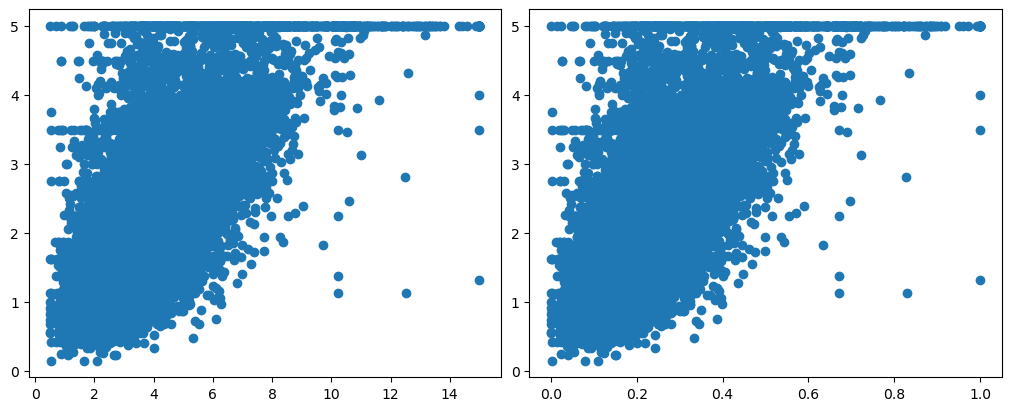

In [8]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=1)

axes[0].scatter(X_train[:, 0], y_train, label="训练集")
axes[1].scatter(X_train_norm[:, 0], y_train, label="训练集")

## 线性回归

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

### 数据预处理

In [10]:
# 加载内置回归数据集
diabetes = load_diabetes()
# 只选取 1 个特征方便绘图（BMI）
X = diabetes.data[:, np.newaxis, 2]  # 特征：BMI
y = diabetes.target  # 标签：疾病进展指标

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 标准化
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

### 训练线性回归模型

In [11]:
model = LinearRegression()
model.fit(X_train_std, y_train)

# 输出模型参数
print(f"线性回归系数 (w)：{model.coef_[0]:.4f}")
print(f"线性回归截距 (b)：{model.intercept_:.4f}\n")

线性回归系数 (w)：47.1411
线性回归截距 (b)：153.7365



### 模型评估

In [12]:
y_pred = model.predict(X_test_std)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"均方误差 (MSE)：{mse:.2f}")
print(f"决定系数 (R²)：{r2:.4f}")

均方误差 (MSE)：4061.83
决定系数 (R²)：0.2334


### 可视化

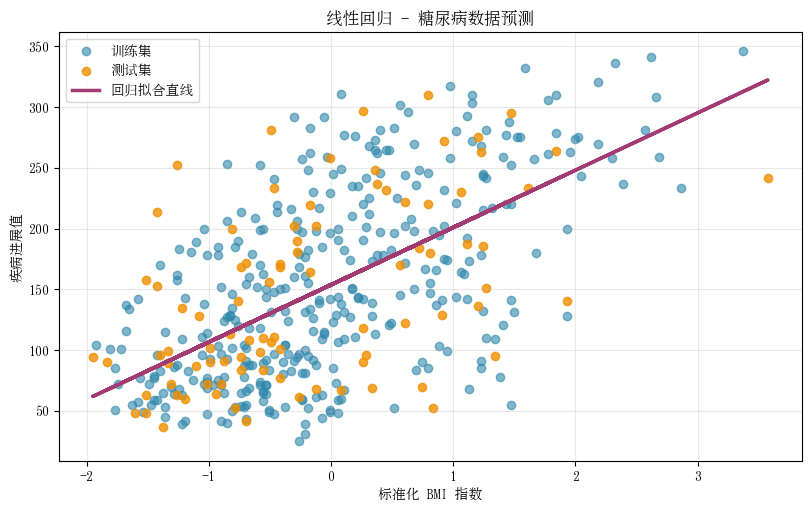

In [13]:
import matplotlib as mpl

# 设置中文字体为宋体或黑体
mpl.rcParams["font.sans-serif"] = ["SimSong"]
# 解决负号显示问题
mpl.rcParams["axes.unicode_minus"] = False

_, ax = plt.subplots(figsize=(8, 5), constrained_layout=1)

# 绘制散点与拟合直线
ax.scatter(X_train_std, y_train, color="#2E86AB", label="训练集", alpha=0.6)
ax.scatter(X_test_std, y_test, color="#F18F01", label="测试集", alpha=0.8)
ax.plot(X_test_std, y_pred, color="#A23B72", linewidth=2.5, label="回归拟合直线")

# 统一设置属性（课程要求）
ax.set(title="线性回归 - 糖尿病数据预测", xlabel="标准化 BMI 指数", ylabel="疾病进展值")
ax.legend()
ax.grid(alpha=0.3)